In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string, re, html

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_orig = pd.read_csv('recipe_reviews.csv')
print(f"Raw dataset shape: {df_orig.shape}")
df_orig.head(2)

Raw dataset shape: (18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

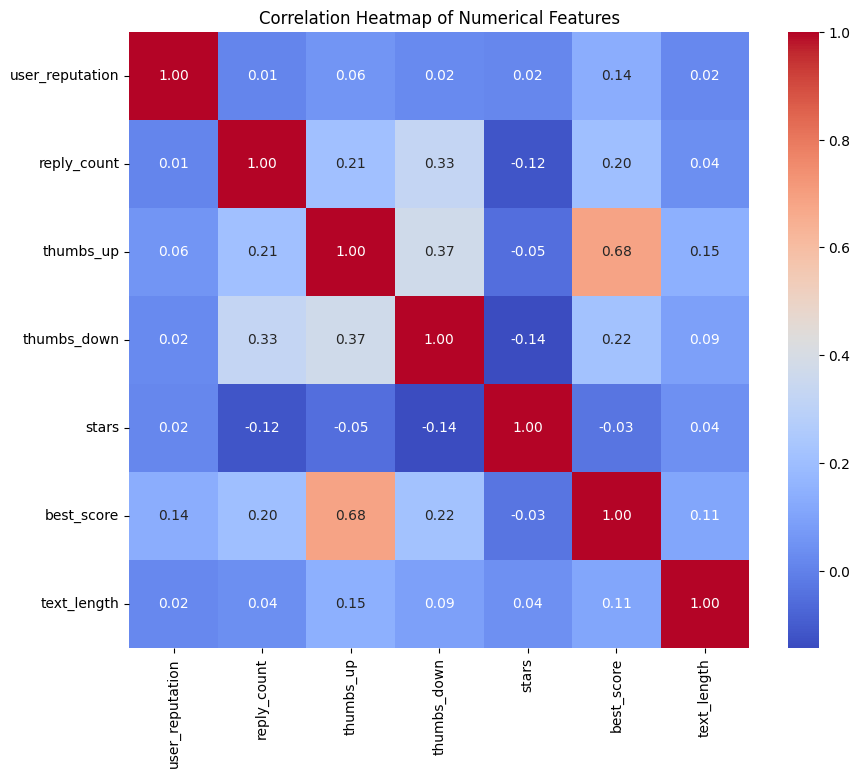

In [3]:
df_orig['text_length'] = df_orig['text'].fillna('').apply(len)

plt.figure(figsize=(10, 8))
numerical_cols = ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text_length']
corr = df_orig[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')

Text(0, 0.5, 'Count')

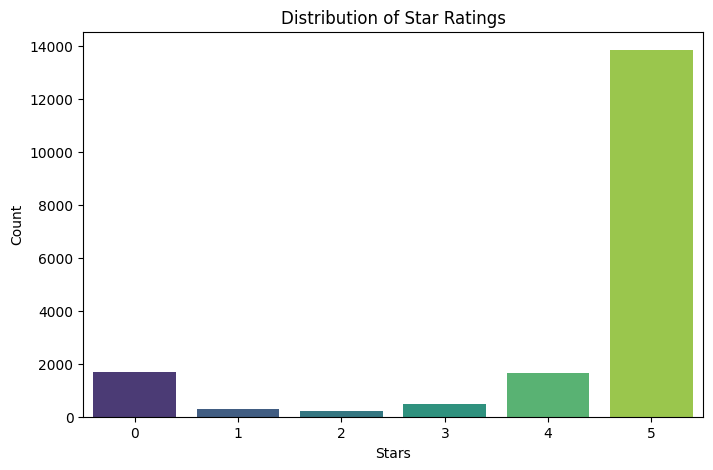

In [4]:
plt.figure(figsize=(8, 5))
star_counts = df_orig['stars'].value_counts().sort_index()
sns.barplot(x=star_counts.index, y=star_counts.values, palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Stars')
plt.ylabel('Count')

(0.0, 843.1899999999987)

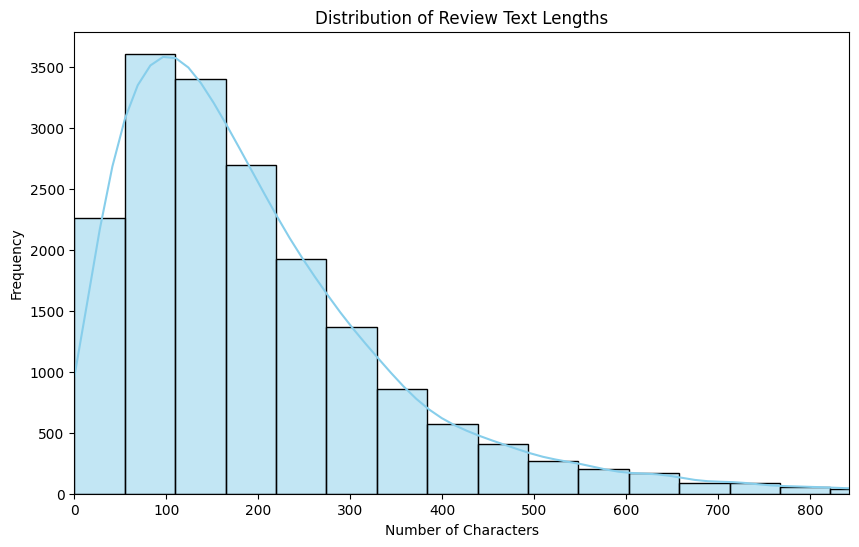

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_orig['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Text Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.xlim(0, df_orig['text_length'].quantile(0.99))

In [6]:
drop_columns = [
    'Unnamed: 0', 'recipe_number', 'recipe_code', 'comment_id',
    'user_name', 'user_id', 'reply_count', 'best_score',
    'user_reputation', 'created_at', 'thumbs_up', 'thumbs_down', 'recipe_name'
]

def clean_text(text: str):
    if not isinstance(text, str):
        return None
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else None

In [7]:
df = df_orig.copy()
print(df.isna().sum())

df = df.drop(columns=[c for c in drop_columns if c in df.columns])
df = df[df['stars'] != 0]
df = df[df['stars'] != 3]   # exclude neutrals


df['sentiment'] = (df['stars'] > 3).astype(int)
print("\nSentiment distribution (no neutrals):")
print(df['sentiment'].value_counts())

df['text'] = df['text'].apply(clean_text)
df = df.dropna(subset=['text']).reset_index(drop=True)
print(f"\nDataset size: {len(df)}")

Unnamed: 0         0
recipe_number      0
recipe_code        0
recipe_name        0
comment_id         0
user_id            0
user_name          0
user_reputation    0
created_at         0
reply_count        0
thumbs_up          0
thumbs_down        0
stars              0
best_score         0
text               2
text_length        0
dtype: int64

Sentiment distribution (no neutrals):
sentiment
1    15484
0      512
Name: count, dtype: int64

Dataset size: 15982


In [8]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])

lengths = pd.Series([len(s) for s in sequences])
print("Length percentiles:")
print(lengths.quantile([0.90, 0.95, 0.99]))
MAX_LEN = int(lengths.quantile(0.95))
print(f"\nmaximum length = {MAX_LEN}")

Length percentiles:
0.90     75.00
0.95     97.00
0.99    153.19
dtype: float64

maximum length = 97


In [9]:
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['sentiment'].values
print(f"X shape: {X.shape}")

indices = np.arange(len(df))
idx_train, idx_test = train_test_split(indices, test_size=0.15, stratify=y, random_state=42)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.2, stratify=y[idx_train], random_state=42)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

X shape: (15982, 97)
Train: 10867 | Val: 2717 | Test: 2398


In [10]:
X_train_t = torch.tensor(X_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64)

In [11]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            batch_first=True,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True
        )
        self.dropout_layer = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        mask = (x != 0).float().unsqueeze(-1)
        pooled = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        pooled = self.layer_norm(pooled)
        pooled = self.dropout_layer(pooled)
        return self.fc(pooled).squeeze(-1)

In [12]:
hidden_dims = [64, 128, 256]
dropouts = [0.2, 0.3, 0.4]

In [13]:
def train_model(hidden_dim, dropout):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SentimentLSTM(
        vocab_size=VOCAB_SIZE,
        embed_dim=128,
        hidden_dim=hidden_dim,
        num_layers=2,
        dropout=dropout
    ).to(device)

    pos_weight = torch.tensor([(neg_count / pos_count) ** 0.5]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3
    )

    best_val_f1 = 0
    patience_counter = 0
    PATIENCE = 7

    for epoch in range(10):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch.to(device))
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_val_f1

In [14]:
neg_count = (y_train_t == 0).sum().item()
pos_count = (y_train_t == 1).sum().item()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pos_weight = torch.tensor([(neg_count / pos_count) ** 0.5]).to(device)
print(f"positive weights: {pos_weight.item():.3f}")

positive weights: 0.182


In [15]:
best_f1 = 0
best_config = None
results = []

for hidden_dim in hidden_dims:
    for dropout in dropouts:
        print(f"\nTraining hidden_dim={hidden_dim}, dropout={dropout}")
        val_f1 = train_model(hidden_dim, dropout)

        results.append({
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "val_f1": val_f1
        })

        print(f"Validation F1: {val_f1:.4f}")
        if val_f1 > best_f1:

            best_f1 = val_f1
            best_config = (hidden_dim, dropout)

print("\nBest configuration:")
print(f"Hidden dim: {best_config[0]}")
print(f"Dropout: {best_config[1]}")
print(f"Best Val F1: {best_f1:.4f}")


Training hidden_dim=64, dropout=0.2
Validation F1: 0.7093

Training hidden_dim=64, dropout=0.3
Validation F1: 0.7091

Training hidden_dim=64, dropout=0.4
Validation F1: 0.7136

Training hidden_dim=128, dropout=0.2
Validation F1: 0.7419

Training hidden_dim=128, dropout=0.3
Validation F1: 0.7702

Training hidden_dim=128, dropout=0.4
Validation F1: 0.7328

Training hidden_dim=256, dropout=0.2
Validation F1: 0.7187

Training hidden_dim=256, dropout=0.3
Validation F1: 0.7469

Training hidden_dim=256, dropout=0.4
Validation F1: 0.7418

Best configuration:
Hidden dim: 128
Dropout: 0.3
Best Val F1: 0.7702


In [16]:
results_df = pd.DataFrame(results)
results_df.sort_values("val_f1", ascending=False)

,hidden_dim,dropout,val_f1
4,128,0.3,0.770165
7,256,0.3,0.746859
3,128,0.2,0.741941
8,256,0.4,0.741828
5,128,0.4,0.732821
6,256,0.2,0.718737
2,64,0.4,0.713635
0,64,0.2,0.709261
1,64,0.3,0.709075


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

best_hidden, best_dropout = best_config

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=best_hidden,
    num_layers=2,
    dropout=best_dropout
)
# model = SentimentLSTM(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4)
model = model.to(device)

neg_count = (y_train_t == 0).sum().item()
pos_count = (y_train_t == 1).sum().item()
pos_weight = torch.tensor([(neg_count / pos_count) ** 0.5]).to(device)
print(f"positive weights: {pos_weight.item():.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Training on: cuda
positive weights: 0.182


In [18]:
best_val_f1 = 0
patience_counter = 0
PATIENCE = 7
history_p1 = []

for epoch in range(50):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch.to(device))
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    scheduler.step(val_f1)
    lr_now = optimizer.param_groups[0]['lr']
    avg_loss = train_loss / len(train_loader)
    history_p1.append({'epoch': epoch+1, 'loss': avg_loss, 'val_f1': val_f1})

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Macro F1: {val_f1:.4f} | LR: {lr_now:.6f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_p1.pt')
        patience_counter = 0
        print(f"Best saved ({val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(torch.load('best_model_p1.pt'))
print(f"\nPhase 1 Best Validation Macro F1: {best_val_f1:.4f}")

Epoch 01 | Loss: 0.0861 | Val Macro F1: 0.5831 | LR: 0.000100
Best saved (0.5831)
Epoch 02 | Loss: 0.0672 | Val Macro F1: 0.6539 | LR: 0.000100
Best saved (0.6539)
Epoch 03 | Loss: 0.0554 | Val Macro F1: 0.6741 | LR: 0.000100
Best saved (0.6741)
Epoch 04 | Loss: 0.0492 | Val Macro F1: 0.6893 | LR: 0.000100
Best saved (0.6893)
Epoch 05 | Loss: 0.0418 | Val Macro F1: 0.6835 | LR: 0.000100
Epoch 06 | Loss: 0.0365 | Val Macro F1: 0.6963 | LR: 0.000100
Best saved (0.6963)
Epoch 07 | Loss: 0.0313 | Val Macro F1: 0.7241 | LR: 0.000100
Best saved (0.7241)
Epoch 08 | Loss: 0.0266 | Val Macro F1: 0.7460 | LR: 0.000100
Best saved (0.7460)
Epoch 09 | Loss: 0.0219 | Val Macro F1: 0.7436 | LR: 0.000100
Epoch 10 | Loss: 0.0183 | Val Macro F1: 0.7496 | LR: 0.000100
Best saved (0.7496)
Epoch 11 | Loss: 0.0178 | Val Macro F1: 0.7070 | LR: 0.000100
Epoch 12 | Loss: 0.0125 | Val Macro F1: 0.7375 | LR: 0.000100
Epoch 13 | Loss: 0.0108 | Val Macro F1: 0.7755 | LR: 0.000100
Best saved (0.7755)
Epoch 14 | Los

In [19]:
model.eval()
val_probs, val_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        out = torch.sigmoid(model(X_batch.to(device)))
        val_probs.extend(out.cpu().numpy())
        val_labels.extend(y_batch.numpy())

best_thresh, best_thresh_f1 = 0.5, 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (np.array(val_probs) >= thresh).astype(float)
    f = f1_score(val_labels, preds, average='macro')
    if f > best_thresh_f1:
        best_thresh_f1 = f
        best_thresh = thresh

print(f"Phase 1 optimal threshold: {best_thresh:.2f} (Validation Macro F1: {best_thresh_f1:.4f})")

Phase 1 optimal threshold: 0.45 (Validation Macro F1: 0.7844)


In [20]:
model.eval()
p1_preds, p1_labels, p1_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = torch.sigmoid(model(X_batch.to(device)))
        preds = (outputs >= best_thresh).float()
        p1_probs.extend(outputs.cpu().numpy())
        p1_preds.extend(preds.cpu().numpy())
        p1_labels.extend(y_batch.numpy())

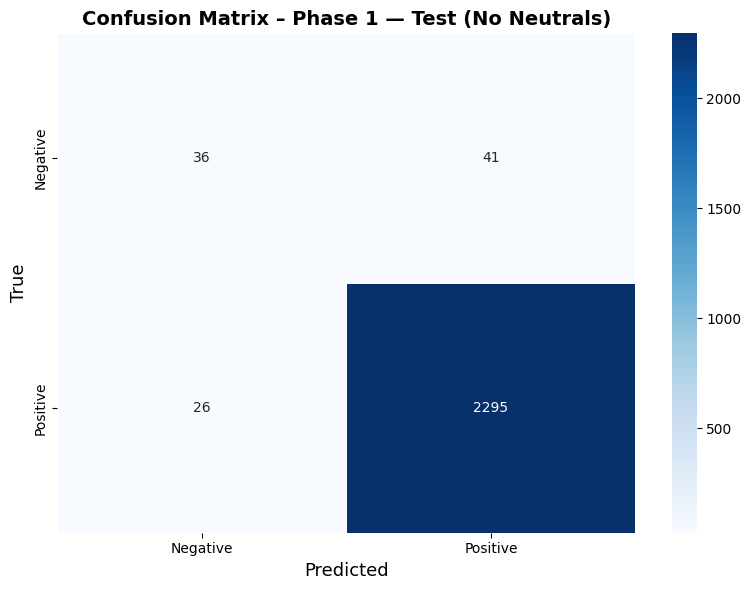

In [21]:
def plot_confusion_matrix(true, pred, label, cmap='Blues'):
    labels = sorted(np.unique(true))
    cm = confusion_matrix(true, pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'], linewidths=0.5)
    plt.xlabel('Predicted', fontsize=13)
    plt.ylabel('True', fontsize=13)
    plt.title(f'Confusion Matrix – {label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(p1_labels, p1_preds, 'Phase 1 — Test (No Neutrals)')

In [22]:
print("Phase 1 Classification Report")
print(classification_report(p1_labels, p1_preds, target_names=['Negative', 'Positive']))

print(f"Macro F1          : {f1_score(p1_labels, p1_preds, average='macro'):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(p1_labels, p1_preds):.4f}")

Phase 1 Classification Report
              precision    recall  f1-score   support

    Negative       0.58      0.47      0.52        77
    Positive       0.98      0.99      0.99      2321

    accuracy                           0.97      2398
   macro avg       0.78      0.73      0.75      2398
weighted avg       0.97      0.97      0.97      2398

Macro F1          : 0.7518
Balanced Accuracy : 0.7282


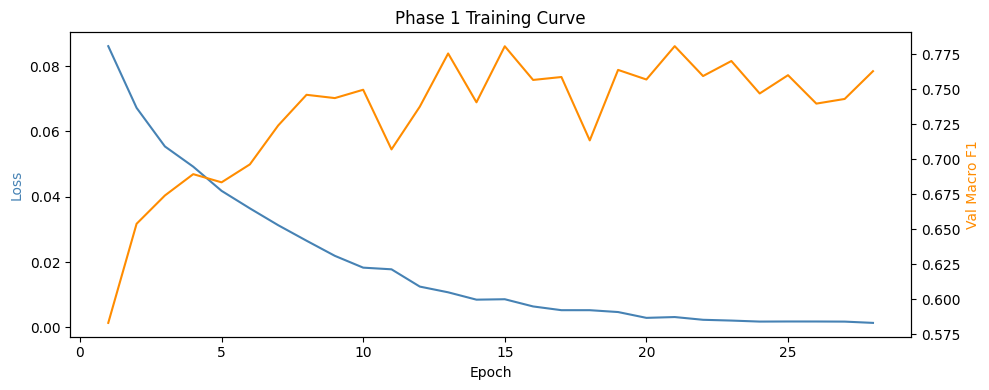

In [23]:
hist_df = pd.DataFrame(history_p1)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(hist_df['epoch'], hist_df['loss'], label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(hist_df['epoch'], hist_df['val_f1'], label='Val Macro F1', color='darkorange')
ax2.set_ylabel('Val Macro F1', color='darkorange')
plt.title('Phase 1 Training Curve')
fig.tight_layout()
plt.show()

In [24]:
df_neutral = df_orig.copy()
df_neutral = df_neutral.drop(columns=[c for c in drop_columns if c in df_neutral.columns])
df_neutral = df_neutral[df_neutral['stars'] == 3].copy()
df_neutral['text'] = df_neutral['text'].apply(clean_text)
df_neutral = df_neutral.dropna(subset=['text']).reset_index(drop=True)
print(f"3 star reviews to classify: {len(df_neutral)}")

3 star reviews to classify: 489


In [25]:
neutral_seqs = tokenizer.texts_to_sequences(df_neutral['text'])
X_neutral    = pad_sequences(neutral_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_neutral_t  = torch.tensor(X_neutral, dtype=torch.long)
neutral_loader = DataLoader(TensorDataset(X_neutral_t), batch_size=64)

In [26]:
model.eval()
neutral_probs = []

with torch.no_grad():
    for (X_batch,) in neutral_loader:
        outputs = torch.sigmoid(model(X_batch.to(device)))
        neutral_probs.extend(outputs.cpu().numpy())

df_neutral['prob'] = neutral_probs
print(f"Statistics for 3-star reviews:")
print(df_neutral['prob'].describe())

Statistics for 3-star reviews:
count    489.000000
mean       0.742164
std        0.403054
min        0.000152
25%        0.405124
50%        0.996607
75%        0.999580
max        0.999871
Name: prob, dtype: float64


In [27]:
low = 0.35
high = 0.65

def sublabel(prob):
    if prob >= high: return 1    # positvie
    elif prob <= low: return 0   # negative
    else: return -1                     # Neither

df_neutral['sub_label'] = df_neutral['prob'].apply(sublabel)
print("Sub-label counts:")
print(df_neutral['sub_label'].value_counts().rename({-1: 'Ambiguous (dropped)', 0: 'Negative', 1: 'Positive'}))

Sub-label counts:
sub_label
Positive               355
Negative               119
Ambiguous (dropped)     15
Name: count, dtype: int64


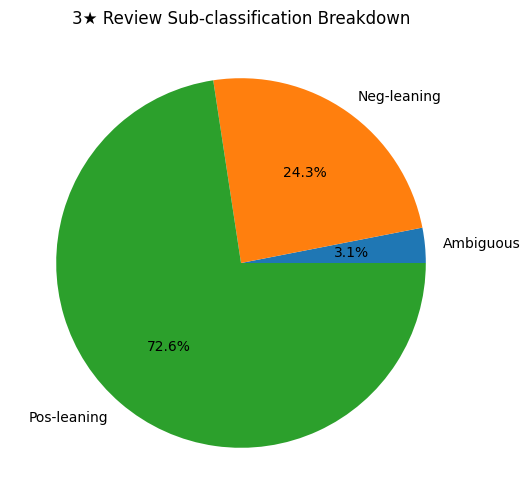

In [28]:
counts = df_neutral['sub_label'].value_counts().sort_index()

plt.figure(figsize=(6, 6))

plt.pie(
    counts,
    labels=['Ambiguous', 'Neg-leaning', 'Pos-leaning'],
    autopct='%1.1f%%'
)

plt.title('3★ Review Sub-classification Breakdown')

plt.show()

In [29]:

relabeled = df_neutral[df_neutral['sub_label'] != -1][['text', 'sub_label', 'stars']].copy()
relabeled = relabeled.rename(columns={'sub_label': 'sentiment'})

df_binary = df[['text', 'sentiment', 'stars']].copy()

df_total = pd.concat([df_binary, relabeled], ignore_index=True)
df_total = df_total.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original binary  : {len(df_binary):>7,} rows")
print(f"Re-labeled added : {len(relabeled):>7,} rows")
print(f"Total  : {len(df_total):>7,} rows")
print("\nSentiment distribution (Training 2):")
print(df_total['sentiment'].value_counts())

Original binary  :  15,982 rows
Re-labeled added :     474 rows
Total  :  16,456 rows

Sentiment distribution (Training 2):
sentiment
1    15825
0      631
Name: count, dtype: int64


In [30]:
tokenizer_p2 = Tokenizer(num_words=VOCAB_SIZE)
tokenizer_p2.fit_on_texts(df_total['text'])
sequences_p2 = tokenizer_p2.texts_to_sequences(df_total['text'])

lengths_p2 = pd.Series([len(s) for s in sequences_p2])
MAX_LEN_P2 = int(lengths_p2.quantile(0.95))
print(f"Phase 2 maximum length = {MAX_LEN_P2}")

X2 = pad_sequences(sequences_p2, maxlen=MAX_LEN_P2, padding='post', truncating='post')
y2 = df_total['sentiment'].values

indices2 = np.arange(len(df_total))
idx2_train, idx2_test = train_test_split(indices2, test_size=0.15, stratify=y2, random_state=42)
idx2_train, idx2_val  = train_test_split(idx2_train, test_size=0.2, stratify=y2[idx2_train], random_state=42)

X2_train, X2_val, X2_test = X2[idx2_train], X2[idx2_val], X2[idx2_test]
y2_train, y2_val, y2_test = y2[idx2_train], y2[idx2_val], y2[idx2_test]

print(f"Phase 2 | Train: {len(X2_train)} | Val: {len(X2_val)} | Test: {len(X2_test)}")

Phase 2 maximum length = 97
Phase 2 | Train: 11189 | Val: 2798 | Test: 2469


In [31]:
X2_train_t = torch.tensor(X2_train, dtype=torch.long)
X2_val_t   = torch.tensor(X2_val,   dtype=torch.long)
X2_test_t  = torch.tensor(X2_test,  dtype=torch.long)
y2_train_t = torch.tensor(y2_train, dtype=torch.float32)
y2_val_t   = torch.tensor(y2_val,   dtype=torch.float32)
y2_test_t  = torch.tensor(y2_test,  dtype=torch.float32)

train2_loader = DataLoader(TensorDataset(X2_train_t, y2_train_t), batch_size=64, shuffle=True)
val2_loader   = DataLoader(TensorDataset(X2_val_t,   y2_val_t),   batch_size=64)
test2_loader  = DataLoader(TensorDataset(X2_test_t,  y2_test_t),  batch_size=64)

In [32]:
# model_p2 = SentimentLSTM(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4)
model_p2 = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=best_hidden,
    num_layers=2,
    dropout=best_dropout
)
model_p2 = model_p2.to(device)

neg2 = (y2_train_t == 0).sum().item()
pos2 = (y2_train_t == 1).sum().item()
pos_weight_p2 = torch.tensor([(neg2 / pos2) ** 0.5]).to(device)
print(f"Phase 2 positive weights: {pos_weight_p2.item():.3f}")

criterion_p2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_p2).to(device)
optimizer_p2 = optim.Adam(model_p2.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p2, mode='max', factor=0.5, patience=3)

Phase 2 positive weights: 0.200


In [33]:
best_val_f1_p2 = 0
patience_counter_p2 = 0
history_p2 = []

for epoch in range(50):
    model_p2.train()
    train_loss = 0

    for X_batch, y_batch in train2_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_p2.zero_grad()
        outputs = model_p2(X_batch)
        loss = criterion_p2(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_p2.parameters(), max_norm=1.0)
        optimizer_p2.step()
        train_loss += loss.item()

    model_p2.eval()
    all_preds_v, all_labels_v = [], []
    with torch.no_grad():
        for X_batch, y_batch in val2_loader:
            outputs = model_p2(X_batch.to(device))
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_v.extend(preds.cpu().numpy())
            all_labels_v.extend(y_batch.numpy())

    val_f1 = f1_score(all_labels_v, all_preds_v, average='macro')
    scheduler_p2.step(val_f1)
    lr_now = optimizer_p2.param_groups[0]['lr']
    avg_loss = train_loss / len(train2_loader)
    history_p2.append({'epoch': epoch+1, 'loss': avg_loss, 'val_f1': val_f1})

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Macro F1: {val_f1:.4f} | LR: {lr_now:.6f}")

    if val_f1 > best_val_f1_p2:
        best_val_f1_p2 = val_f1
        torch.save(model_p2.state_dict(), 'best_model_p2.pt')
        patience_counter_p2 = 0
        print(f"Best saved ({val_f1:.4f})")
    else:
        patience_counter_p2 += 1
        if patience_counter_p2 >= PATIENCE:
            print("Early stopping")
            break

model_p2.load_state_dict(torch.load('best_model_p2.pt'))
print(f"\nPhase 2 Best Val Macro F1: {best_val_f1_p2:.4f}")

Epoch 01 | Loss: 0.0972 | Val Macro F1: 0.6332 | LR: 0.000100
Best saved (0.6332)
Epoch 02 | Loss: 0.0723 | Val Macro F1: 0.6982 | LR: 0.000100
Best saved (0.6982)
Epoch 03 | Loss: 0.0597 | Val Macro F1: 0.7104 | LR: 0.000100
Best saved (0.7104)
Epoch 04 | Loss: 0.0501 | Val Macro F1: 0.7304 | LR: 0.000100
Best saved (0.7304)
Epoch 05 | Loss: 0.0444 | Val Macro F1: 0.7406 | LR: 0.000100
Best saved (0.7406)
Epoch 06 | Loss: 0.0373 | Val Macro F1: 0.7434 | LR: 0.000100
Best saved (0.7434)
Epoch 07 | Loss: 0.0316 | Val Macro F1: 0.7492 | LR: 0.000100
Best saved (0.7492)
Epoch 08 | Loss: 0.0276 | Val Macro F1: 0.7457 | LR: 0.000100
Epoch 09 | Loss: 0.0224 | Val Macro F1: 0.7590 | LR: 0.000100
Best saved (0.7590)
Epoch 10 | Loss: 0.0190 | Val Macro F1: 0.7477 | LR: 0.000100
Epoch 11 | Loss: 0.0144 | Val Macro F1: 0.7689 | LR: 0.000100
Best saved (0.7689)
Epoch 12 | Loss: 0.0132 | Val Macro F1: 0.7869 | LR: 0.000100
Best saved (0.7869)
Epoch 13 | Loss: 0.0112 | Val Macro F1: 0.7703 | LR: 0.0

In [34]:
model_p2.eval()
val2_probs, val2_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val2_loader:
        out = torch.sigmoid(model_p2(X_batch.to(device)))
        val2_probs.extend(out.cpu().numpy())
        val2_labels.extend(y_batch.numpy())

best_thresh_p2, best_f1_p2 = 0.5, 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (np.array(val2_probs) >= thresh).astype(float)
    f = f1_score(val2_labels, preds, average='macro')
    if f > best_f1_p2:
        best_f1_p2 = f
        best_thresh_p2 = thresh

print(f"Phase 2 optimal threshold: {best_thresh_p2:.2f} (Val Macro F1: {best_f1_p2:.4f})")

Phase 2 optimal threshold: 0.47 (Val Macro F1: 0.7897)


In [35]:
model_p2.eval()
p2_preds, p2_labels, p2_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test2_loader:
        outputs = torch.sigmoid(model_p2(X_batch.to(device)))
        preds = (outputs >= best_thresh_p2).float()
        p2_probs.extend(outputs.cpu().numpy())
        p2_preds.extend(preds.cpu().numpy())
        p2_labels.extend(y_batch.numpy())

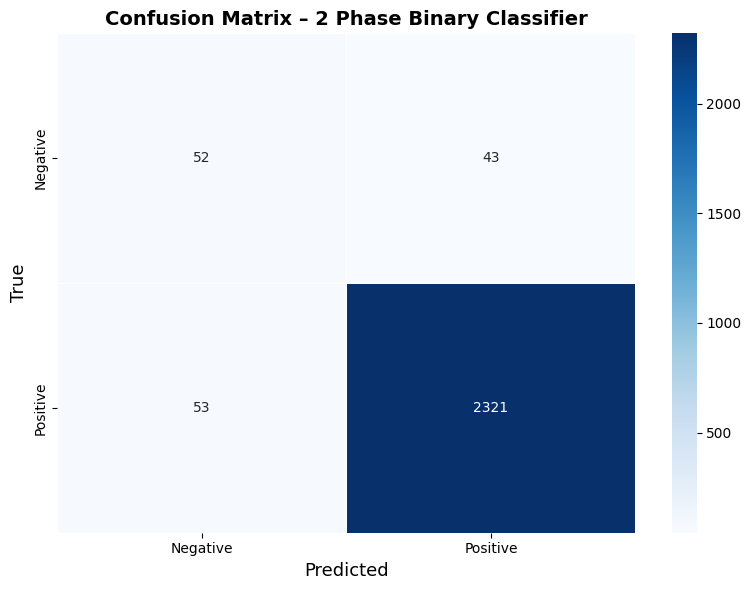

In [43]:
plot_confusion_matrix(p2_labels, p2_preds, '2 Phase Binary Classifier')

In [37]:
print("Phase 2 Classification Report")
print(classification_report(p2_labels, p2_preds, target_names=['Negative', 'Positive']))

print(f"Macro F1          : {f1_score(p2_labels, p2_preds, average='macro'):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(p2_labels, p2_preds):.4f}")

Phase 2 Classification Report
              precision    recall  f1-score   support

    Negative       0.50      0.55      0.52        95
    Positive       0.98      0.98      0.98      2374

    accuracy                           0.96      2469
   macro avg       0.74      0.76      0.75      2469
weighted avg       0.96      0.96      0.96      2469

Macro F1          : 0.7499
Balanced Accuracy : 0.7625


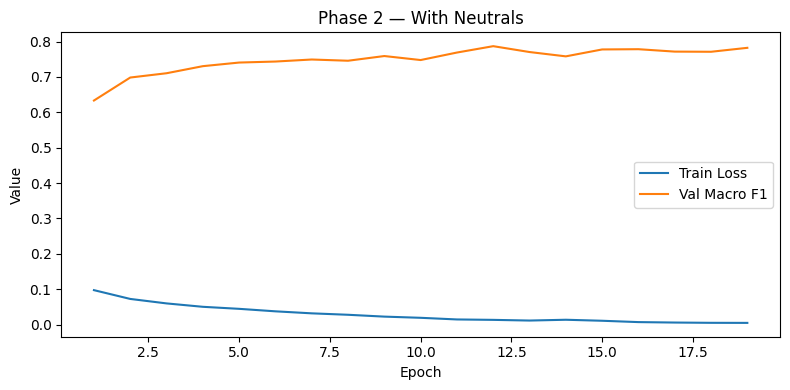

In [38]:
hdf = pd.DataFrame(history_p2)
plt.figure(figsize=(8, 4))

# Train Loss
plt.plot(hdf['epoch'], hdf['loss'], label='Train Loss')

# Val F1 (same plot, since no twin axis)
plt.plot(hdf['epoch'], hdf['val_f1'], label='Val Macro F1')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Phase 2 — With Neutrals')

plt.legend()
plt.tight_layout()
plt.show()

In [39]:
test2_texts = df_total.iloc[idx2_test]['text'].values
test2_stars = df_total.iloc[idx2_test]['stars'].values

label_map = {0: 'Negative', 1: 'Positive'}
p2_probs_arr  = np.array(p2_probs)
p2_preds_arr  = np.array(p2_preds)
p2_labels_arr = np.array(p2_labels)
correct_mask_p2 = p2_preds_arr == p2_labels_arr

misclassified_p2 = []
for i in np.where(~correct_mask_p2)[0]:
    misclassified_p2.append({
        'text':       test2_texts[i][:250],
        'stars':      test2_stars[i],
        'true_label': label_map[int(p2_labels_arr[i])],
        'pred_label': label_map[int(p2_preds_arr[i])],
        'confidence': round(float(p2_probs_arr[i]), 3)
    })

miss_df_p2 = pd.DataFrame(misclassified_p2)
print(f"Total misclassified: {len(miss_df_p2)} / {len(p2_labels_arr)} ({len(miss_df_p2)/len(p2_labels_arr)*100:.1f}%)")
miss_df_p2

Total misclassified: 96 / 2469 (3.9%)


,text,stars,true_label,pred_label,confidence
0,first pie ive ever made turned out perfect tar...,5,Positive,Negative,0.033
1,the recipe just seemed to lack a little someth...,3,Negative,Positive,0.998
2,not a fan of horseradish sauce or swiss cheese...,5,Positive,Negative,0.027
3,made this today for supper and was somewhat di...,2,Negative,Positive,0.999
4,i used half the sugar so it wasnt overly sweet...,2,Negative,Positive,0.619
...,...,...,...,...,...
91,soup is fine but the ranch dressing mix was le...,4,Positive,Negative,0.077
92,i felt it was somewhat bland i added celery se...,4,Positive,Negative,0.137
93,i changed things no sugar used ricotta cheese,5,Positive,Negative,0.135
94,made this for dinner last night it wasnt bad b...,4,Positive,Negative,0.009


In [40]:
miss_df_p2['conf_error'] = miss_df_p2.apply(
    lambda r: r['confidence'] if r['pred_label'] == 'Positive' else 1 - r['confidence'], axis=1
)
print("Top 10 Most Confidently Misclassified (Phase 2)")
display(miss_df_p2.sort_values('conf_error', ascending=False).head(10).drop(columns='conf_error'))

Top 10 Most Confidently Misclassified (Phase 2)


,text,stars,true_label,pred_label,confidence
3,made this today for supper and was somewhat di...,2,Negative,Positive,0.999
70,as written this has far too much sugar for my ...,3,Positive,Negative,0.001
89,the recipe was blend so i ate dried herbs more...,2,Negative,Positive,0.999
86,while i think these would be fun for kids as t...,3,Negative,Positive,0.999
49,this makes a good chowder base but using canne...,2,Negative,Positive,0.999
55,really bland looked super delicious in the pic...,1,Negative,Positive,0.999
58,this recipe has been on allrecipescom for year...,1,Negative,Positive,0.999
59,my rating has to do with the equipment used th...,2,Negative,Positive,0.999
36,it was decent i think too much sugar for my taste,4,Positive,Negative,0.002
1,the recipe just seemed to lack a little someth...,3,Negative,Positive,0.998


In [41]:
top10_misclassified = (
    miss_df_p2
    .sort_values('conf_error', ascending=False)
    .head(10)
    .drop(columns='conf_error')
)

top10_misclassified.to_csv("top10_misclassified_phase2.csv", index=False)

In [42]:
summary = pd.DataFrame({
    'Phase': ['Phase 1 (No Neutrals)', 'Phase 2 (With Neutrals)'],
    'Test Size':       [len(p1_labels), len(p2_labels)],
    'Macro F1':        [round(f1_score(p1_labels, p1_preds, average='macro'), 4),
                        round(f1_score(p2_labels, p2_preds, average='macro'), 4)],
    'Balanced Acc':    [round(balanced_accuracy_score(p1_labels, p1_preds), 4),
                        round(balanced_accuracy_score(p2_labels, p2_preds), 4)],
    'Misclassified %': [round(len(miss_df_p2)*0 + (1 - np.mean(np.array(p1_preds)==np.array(p1_labels)))*100, 2),
                        round((1 - np.mean(correct_mask_p2))*100, 2)]
})

summary = summary.set_index('Phase')
display(summary)

,Test Size,Macro F1,Balanced Acc,Misclassified %
Phase,,,,
Phase 1 (No Neutrals),2398,0.7518,0.7282,2.79
Phase 2 (With Neutrals),2469,0.7499,0.7625,3.89
